# Task 12: Convolutional Autoencoder for Anomaly Detection



In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter
from sklearn.metrics import roc_auc_score

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Create Simple Fault-Free Training Images

For a real manufacturing dataset, replace these images with normal/fault-free images.

Here we create simple images containing a normal circular structure.

In [2]:
def make_normal_images(n=200, size=64):

    images = []

    for _ in range(n):

        img = np.zeros((size, size), dtype=np.float32)

        # Normal circular structure
        yy, xx = np.ogrid[:size, :size]

        cx, cy = size // 2, size // 2

        circle = (
            (xx - cx) ** 2
            + (yy - cy) ** 2
            < 18 ** 2
        )

        img[circle] = 1.0

        # Small noise makes the task less artificial.
        img += np.random.normal(
            0, 0.03, img.shape
        )

        images.append(
            np.clip(img, 0, 1)
        )

    return np.array(images)


normal_images = make_normal_images()

X_train = torch.tensor(
    normal_images
).unsqueeze(1).float()

train_loader = DataLoader(
    TensorDataset(X_train),
    batch_size=16,
    shuffle=True
)

print("Training images:", X_train.shape)

Training images: torch.Size([200, 1, 64, 64])


## 2. Convolutional Autoencoder

In [3]:
class Autoencoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.ReLU(),

            nn.Flatten(),

            # Dense structural bottleneck
            nn.Linear(16 * 16 * 16, 32),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(32, 16 * 16 * 16),
            nn.ReLU(),

            nn.Unflatten(
                1, (16, 16, 16)
            ),

            nn.ConvTranspose2d(
                16, 8, 4,
                stride=2,
                padding=1
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                8, 1, 4,
                stride=2,
                padding=1
            ),

            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)


model = Autoencoder().to(device)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=4096, out_features=32, bias=True)
    (6): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=4096, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(16, 16, 16))
    (3): ConvTranspose2d(16, 8, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(8, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (6): Sigmoid()
  )
)


## 3. Simple SSIM Loss



In [4]:
def ssim_loss(x, y):

    # Local means
    mu_x = gaussian_filter(
        x.detach().cpu().numpy(),
        sigma=1
    )

    mu_y = gaussian_filter(
        y.detach().cpu().numpy(),
        sigma=1
    )

    # For a simple implementation, use MSE as
    # the differentiable reconstruction component.
    #
    # The SSIM-style local statistics are used as
    # an additional structural measurement.
    mu_x = torch.tensor(mu_x, device=x.device)
    mu_y = torch.tensor(mu_y, device=x.device)

    c1 = 0.01 ** 2

    structural_difference = (
        (mu_x - mu_y) ** 2
    ).mean()

    return structural_difference


def combined_loss(output, target):

    mse = nn.functional.mse_loss(
        output,
        target
    )

    ssim = ssim_loss(
        output,
        target
    )

    return mse + ssim

## 4. Train Only on Fault-Free Images

In [5]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10
loss_history = []

model.train()

for epoch in range(epochs):

    total_loss = 0

    for (images,) in train_loader:

        images = images.to(device)

        optimizer.zero_grad()

        reconstructed = model(images)

        loss = combined_loss(
            reconstructed,
            images
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"- Loss: {avg_loss:.4f}"
    )

Epoch 1/10 - Loss: 0.4096
Epoch 2/10 - Loss: 0.3408
Epoch 3/10 - Loss: 0.1688
Epoch 4/10 - Loss: 0.0339
Epoch 5/10 - Loss: 0.0153
Epoch 6/10 - Loss: 0.0120
Epoch 7/10 - Loss: 0.0116
Epoch 8/10 - Loss: 0.0111
Epoch 9/10 - Loss: 0.0109
Epoch 10/10 - Loss: 0.0105


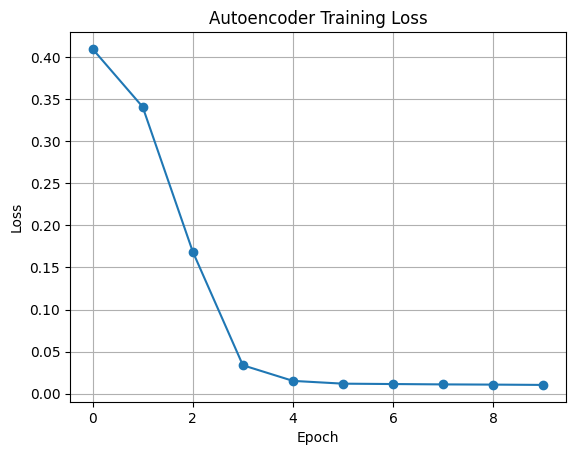

In [6]:
plt.plot(loss_history, marker="o")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.grid()
plt.show()

## 5. Create Test Images with Anomalies

The model has never seen these defects during training.

We add a small square defect to some images.

In [7]:
test_images = normal_images[:20].copy()

labels = np.zeros(20)

for i in range(10):

    # Add an artificial defect
    test_images[i, 10:18, 10:18] = 1.0

    labels[i] = 1

X_test = torch.tensor(
    test_images
).unsqueeze(1).float()

print("Anomalous test images:", int(labels.sum()))

Anomalous test images: 10


## 6. Reconstruction Error Map

A defect should produce a larger reconstruction error.

The error map is calculated pixel by pixel.

In [8]:
model.eval()

with torch.no_grad():

    reconstructed = model(
        X_test.to(device)
    ).cpu()

# Pixel-wise reconstruction error
error_map = (
    (X_test - reconstructed) ** 2
).squeeze(1)

# One anomaly score per image
scores = error_map.mean(
    dim=(1, 2)
).numpy()

print("Anomaly scores:")
print(scores)

Anomaly scores:
[0.02402218 0.024057   0.02401119 0.02412496 0.02412394 0.02398718
 0.02394425 0.0239144  0.02406075 0.02395326 0.00838803 0.00844774
 0.00845749 0.00842935 0.00844615 0.00843658 0.00830527 0.00840781
 0.00847787 0.0084732 ]


## 7. Detect Anomalies with Scikit-Learn

A simple ROC-AUC score shows how well the reconstruction error separates normal and anomalous images.

In [9]:
auc = roc_auc_score(
    labels,
    scores
)

print("ROC-AUC:", auc)

# Simple threshold
threshold = np.mean(scores) + np.std(scores)

predicted = (
    scores > threshold
).astype(int)

print("Predicted anomalies:", predicted)

ROC-AUC: 1.0
Predicted anomalies: [1 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]


## 8. Visualize the Reconstruction Error

The error heatmap shows where the model is struggling to reconstruct the image.

Bright regions indicate possible anomalies.

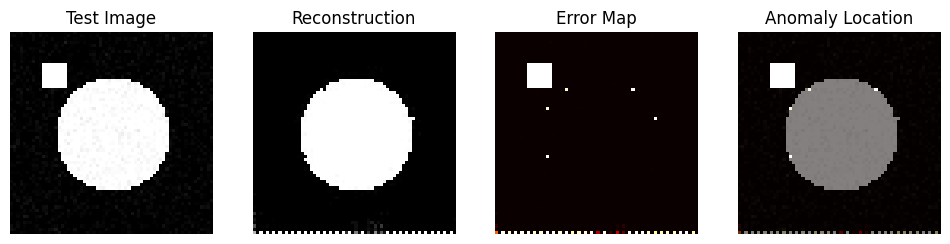

In [10]:
index = 0

plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.imshow(X_test[index, 0], cmap="gray")
plt.title("Test Image")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(reconstructed[index, 0], cmap="gray")
plt.title("Reconstruction")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(error_map[index], cmap="hot")
plt.title("Error Map")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(
    X_test[index, 0],
    cmap="gray"
)
plt.imshow(
    error_map[index],
    cmap="hot",
    alpha=0.5
)
plt.title("Anomaly Location")
plt.axis("off")

plt.show()